# 🏭 Decision Tree Classification — Chemical Engineering
## Automated Fault Detection in a Distillation Column

---

### 📚 Learning Objectives
By the end of this notebook you will be able to:
1. Understand how Decision Trees work conceptually (no black-box magic!).
2. Apply a Decision Tree classifier to a real-world Chemical Engineering problem.
3. Evaluate model performance using classification metrics.
4. Visualise the tree and interpret its decisions.
5. Critically assess the **pros and cons** of Decision Trees in process automation.

---

### 🏭 Real-World Context

**Distillation columns** are the backbone of the petrochemical, pharmaceutical, and food-processing industries. They separate liquid mixtures by exploiting differences in volatility. 

In large plants, columns operate continuously for months. Faults — flooding, weeping, entrainment, fouling — can lead to:
- Product purity failures (costly reprocessing or recalls)
- Equipment damage
- Safety incidents

Traditionally, operators rely on manual inspection and rule-of-thumb thresholds. **Supervised ML classification** offers an automated, data-driven alternative: given live sensor readings, predict the operational state of the column *before* a fault becomes catastrophic.

> **Dataset note:** We generate a synthetic but physically meaningful dataset using domain knowledge. Real datasets (e.g. from COCO, Tennessee Eastman Process) require licensed access; the patterns here mirror published literature.


---
## 1. Theory: How Does a Decision Tree Work?

A Decision Tree is a **flowchart-like model** that splits data recursively based on feature values.

```
          [Root: ΔP > 12 kPa?]
               /         \
             YES           NO
          [Flooding?]   [T_top < 78°C?]
           /    \           /       \
         YES    NO        YES        NO
       FLOOD  CHECK    WEEPING    NORMAL
```

### Key Concepts

| Term | Meaning |
|------|----------|
| **Node** | A question / decision point |
| **Branch** | Outcome of a question (yes/no or threshold) |
| **Leaf** | Final class prediction |
| **Depth** | Number of layers in the tree |
| **Gini Impurity** | Measure of how mixed classes are in a node (0 = pure) |
| **Information Gain** | Reduction in impurity after a split |

### Splitting Criterion — Gini Impurity

$$G = 1 - \sum_{k=1}^{K} p_k^2$$

where $p_k$ is the proportion of class $k$ at a node. The algorithm searches for the feature and threshold that **minimises** weighted Gini impurity after the split.

### Splitting Criterion — Information Gain (Entropy)

$$H = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

$$\text{Gain} = H(\text{parent}) - \frac{N_{left}}{N} H(\text{left}) - \frac{N_{right}}{N} H(\text{right})$$


---
## 2. Setup — Install & Import Libraries

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Numerical & data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, roc_auc_score
)
from sklearn.inspection import DecisionBoundaryDisplay

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


---
## 3. Dataset Generation — Distillation Column Sensor Data

### Process Variables (Features)

| Feature | Symbol | Units | Physical Meaning |
|---------|--------|-------|------------------|
| Column pressure drop | `delta_P` | kPa | Resistance to vapour flow up the column |
| Top temperature | `T_top` | °C | Indicative of light-key concentration at overhead |
| Bottom temperature | `T_bot` | °C | Indicative of heavy-key concentration at base |
| Reflux flow rate | `reflux` | kg/hr | Liquid returned from condenser |
| Feed flow rate | `feed` | kg/hr | Incoming mixture |
| Reboiler duty | `Q_reb` | kW | Heat supplied at base |
| Overhead vapour rate | `V_OH` | kg/hr | Vapour leaving condenser |
| Tray 10 temperature | `T_tray10` | °C | Mid-column process indicator |

### Target Classes

| Class | Label | Description |
|-------|-------|-------------|
| 0 | `Normal` | Steady-state operation |
| 1 | `Flooding` | Vapour velocity too high — liquid back-up |
| 2 | `Weeping` | Vapour velocity too low — liquid draining through trays |
| 3 | `Fouling` | Deposit build-up reducing mass transfer efficiency |


In [2]:
def generate_distillation_data(n_samples: int = 1200, seed: int = 42) -> pd.DataFrame:
    """
    Generate synthetic distillation column sensor data.
    Patterns are grounded in chemical engineering principles:
      - Flooding  → high ΔP, high reflux, high V_OH
      - Weeping   → low ΔP, low reflux, low V_OH, high T_bot
      - Fouling   → moderate ΔP slowly rising, diverging tray temperatures
      - Normal    → all variables within design envelope
    """
    rng = np.random.default_rng(seed)
    n_each = n_samples // 4
    records = []

    # ── Normal operation ──────────────────────────────────────────────────────
    for _ in range(n_each):
        records.append({
            'delta_P':  rng.normal(8.0,  0.8),
            'T_top':    rng.normal(78.0, 1.2),
            'T_bot':    rng.normal(105.0, 1.5),
            'reflux':   rng.normal(500.0, 20.0),
            'feed':     rng.normal(1000.0, 30.0),
            'Q_reb':    rng.normal(350.0, 15.0),
            'V_OH':     rng.normal(480.0, 18.0),
            'T_tray10': rng.normal(91.0,  1.0),
            'fault':    'Normal'
        })

    # ── Flooding ──────────────────────────────────────────────────────────────
    for _ in range(n_each):
        records.append({
            'delta_P':  rng.normal(18.0, 1.5),   # significantly elevated
            'T_top':    rng.normal(82.0, 2.0),   # slight rise (liquid entrainment)
            'T_bot':    rng.normal(106.0, 1.8),
            'reflux':   rng.normal(700.0, 30.0), # high reflux driving flooding
            'feed':     rng.normal(1000.0, 40.0),
            'Q_reb':    rng.normal(420.0, 20.0), # high reboiler duty
            'V_OH':     rng.normal(680.0, 25.0), # high vapour rate
            'T_tray10': rng.normal(95.0,  2.0),
            'fault':    'Flooding'
        })

    # ── Weeping ───────────────────────────────────────────────────────────────
    for _ in range(n_each):
        records.append({
            'delta_P':  rng.normal(3.5, 0.6),    # low — vapour not supporting liquid
            'T_top':    rng.normal(74.0, 1.5),   # cooler top (less separation)
            'T_bot':    rng.normal(110.0, 2.0),  # hotter base
            'reflux':   rng.normal(280.0, 25.0), # low reflux
            'feed':     rng.normal(1000.0, 35.0),
            'Q_reb':    rng.normal(200.0, 20.0), # low duty
            'V_OH':     rng.normal(250.0, 20.0), # low vapour rate
            'T_tray10': rng.normal(86.0,  2.0),
            'fault':    'Weeping'
        })

    # ── Fouling ───────────────────────────────────────────────────────────────
    for _ in range(n_each):
        records.append({
            'delta_P':  rng.normal(11.0, 1.2),   # moderately elevated
            'T_top':    rng.normal(80.5, 2.5),   # unstable
            'T_bot':    rng.normal(108.0, 2.5),
            'reflux':   rng.normal(510.0, 40.0),
            'feed':     rng.normal(1000.0, 30.0),
            'Q_reb':    rng.normal(390.0, 30.0), # higher duty to compensate
            'V_OH':     rng.normal(460.0, 30.0),
            'T_tray10': rng.normal(97.0,  3.5),  # large spread — fouling uneven
            'fault':    'Fouling'
        })

    df = pd.DataFrame(records).sample(frac=1, random_state=seed).reset_index(drop=True)
    return df


df = generate_distillation_data(n_samples=1200)
print(f'Dataset shape: {df.shape}')
print(f"Class distribution:\n{df['fault'].value_counts()}")
df.head(10)

Dataset shape: (1200, 9)
Class distribution:
fault
Fouling     300
Weeping     300
Normal      300
Flooding    300
Name: count, dtype: int64


,delta_P,T_top,T_bot,reflux,feed,Q_reb,V_OH,T_tray10,fault
0,9.598014,85.545276,106.102042,509.650024,965.200317,351.055230,433.767148,93.603169,Fouling
1,4.342374,71.866087,109.599574,306.145765,998.943530,180.412117,223.026487,85.540002,Weeping
2,7.744715,78.260677,104.696875,488.442118,1007.586544,342.440634,468.694810,91.311453,Normal
3,17.061564,84.151446,106.642161,690.865666,1017.858441,418.798155,680.314463,96.313637,Flooding
4,7.106093,77.449590,104.560213,538.744623,1033.179801,335.568633,486.258752,90.592922,Normal
5,10.750194,81.410103,107.792872,447.920554,1056.566707,420.126539,449.938676,95.967169,Fouling
6,18.690328,83.988701,106.148893,742.304860,1012.376514,432.483685,659.168435,99.317318,Flooding
7,10.807255,79.482481,110.928811,462.131995,982.685585,363.046786,503.275912,93.957070,Fouling
8,17.390800,79.942992,105.609141,708.320325,980.210063,431.079070,665.425153,96.240745,Flooding
9,4.564509,72.814417,111.485655,278.508288,988.529015,212.646307,244.016530,80.676069,Weeping


---
## 4. Exploratory Data Analysis (EDA)

In [3]:
# ── Descriptive statistics by fault class ────────────────────────────────────
df.groupby('fault').agg(['mean', 'std']).round(2)

delta_P        T_top         T_bot        reflux            feed  \
            mean   std   mean   std    mean   std    mean    std     mean   
fault                                                                       
Flooding   18.06  1.42  82.06  1.97  106.10  1.79  700.80  30.64  1000.71   
Fouling    10.90  1.26  80.55  2.51  108.17  2.32  503.47  41.99   997.61   
Normal      7.94  0.78  77.94  1.17  104.87  1.56  499.57  19.69  1000.45   
Weeping     3.55  0.59  74.10  1.54  110.14  1.96  279.70  25.89  1000.91   

                  Q_reb           V_OH        T_tray10        
            std    mean    std    mean    std     mean   std  
fault                                                         
Flooding  40.80  420.18  19.37  677.27  23.93    95.02  2.14  
Fouling   30.39  389.89  29.76  458.86  29.22    96.91  3.60  
Normal    29.31  349.87  15.99  479.33  18.52    90.92  0.98  
Weeping   32.93  199.61  21.33  250.88  20.42    85.90  2.09

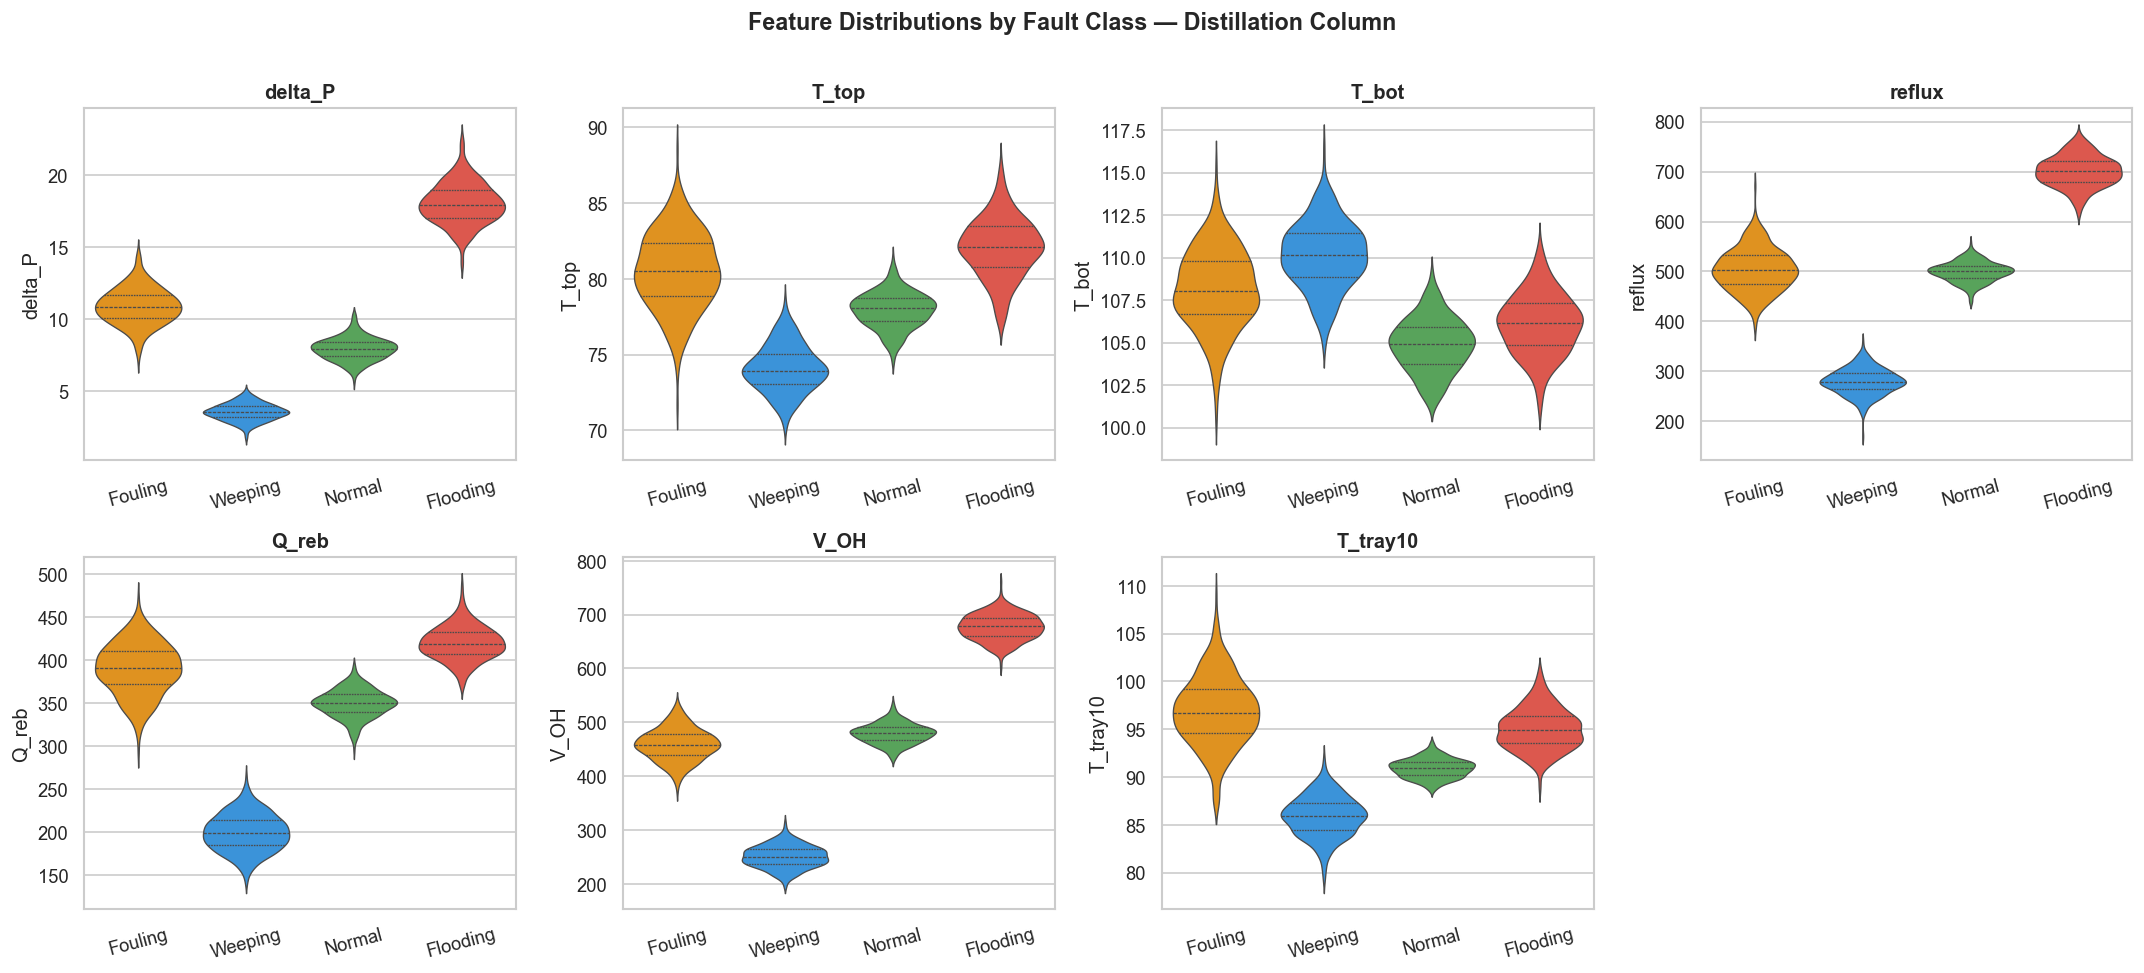

In [4]:
# ── Violin plots: feature distributions per class ────────────────────────────
features = ['delta_P', 'T_top', 'T_bot', 'reflux', 'Q_reb', 'V_OH', 'T_tray10']
palette  = {'Normal': '#4CAF50', 'Flooding': '#F44336',
             'Weeping': '#2196F3', 'Fouling': '#FF9800'}

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.violinplot(data=df, x='fault', y=feat, palette=palette,
                   ax=axes[i], inner='quartile', linewidth=0.8)
    axes[i].set_title(f'{feat}', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions by Fault Class — Distillation Column',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

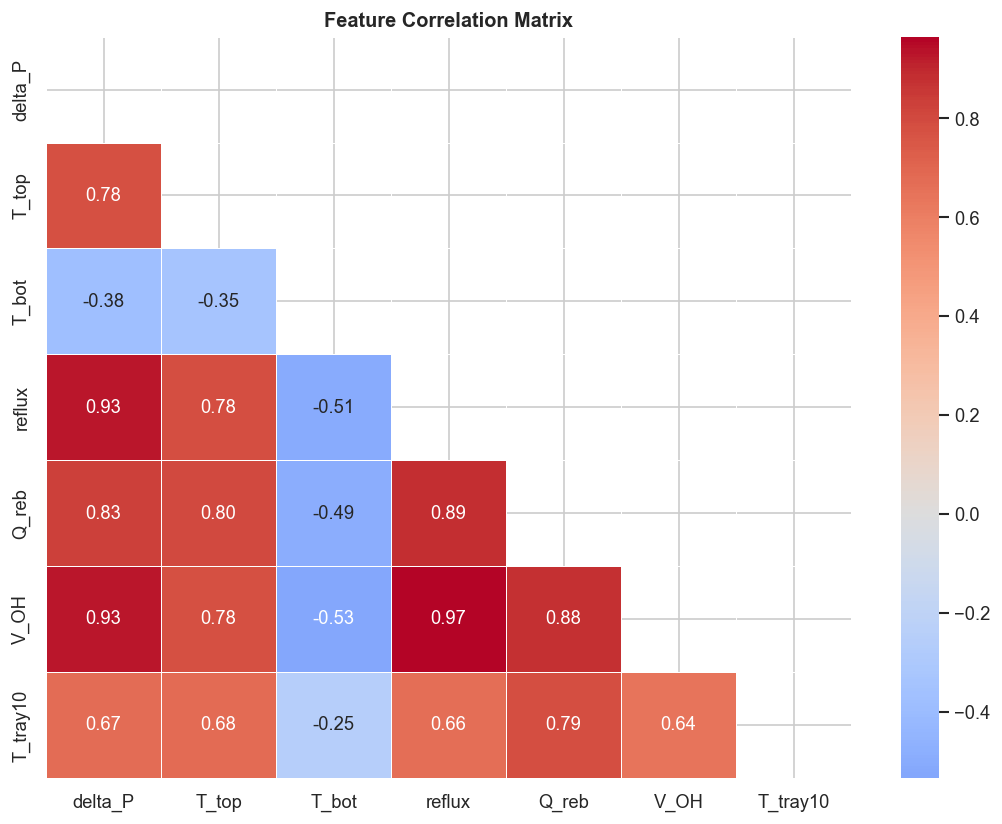

In [5]:
# ── Correlation heatmap (numeric features only) ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Observation:** `delta_P`, `reflux`, `V_OH`, and `Q_reb` are highly correlated — they are all driven by vapour/liquid traffic in the column. This means a tree split on one of these implicitly captures the others. Decision Trees handle correlated features reasonably but Random Forests do better (see Cons section).

---
## 5. Data Preprocessing

In [6]:
# ── Encode target ─────────────────────────────────────────────────────────────
le = LabelEncoder()
y = le.fit_transform(df['fault'])          # 0=Flooding 1=Fouling 2=Normal 3=Weeping
X = df[features].values

print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

# NOTE: Decision Trees do NOT require feature scaling (they use threshold splits)
# but we scale for completeness and comparison with other models later.
scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

Class mapping: {'Flooding': 0, 'Fouling': 1, 'Normal': 2, 'Weeping': 3}

Training samples : 900
Test samples     : 300


---
## 6. Train a Decision Tree Classifier

In [7]:
# ── Initial tree (no depth limit — prone to overfitting) ─────────────────────
dt_full = DecisionTreeClassifier(criterion='gini', random_state=SEED)
dt_full.fit(X_train, y_train)

# ── Pruned / limited tree ─────────────────────────────────────────────────────
dt_pruned = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,          # controls overfitting
    min_samples_split=15, # node must have ≥15 samples to split
    min_samples_leaf=6,   # leaf must have ≥6 samples
    random_state=SEED
)
dt_pruned.fit(X_train, y_train)

# ── Quick comparison ──────────────────────────────────────────────────────────
for name, model in [('Full tree', dt_full), ('Pruned tree (depth=5)', dt_pruned)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    depth     = model.get_depth()
    n_leaves  = model.get_n_leaves()
    print(f'{name:30s} | Depth={depth:3d} | Leaves={n_leaves:4d} | '
          f'Train Acc={train_acc:.3f} | Test Acc={test_acc:.3f}')

Full tree                      | Depth=  8 | Leaves=  13 | Train Acc=1.000 | Test Acc=0.990
Pruned tree (depth=5)          | Depth=  5 | Leaves=   8 | Train Acc=0.991 | Test Acc=0.980


**💡 Key insight:** The unpruned tree memorises the training set (near-perfect train accuracy) but generalises no better than the pruned version — a classic demonstration of **overfitting**.

---
## 7. Hyperparameter Tuning with Grid Search

In [8]:
param_grid = {
    'max_depth'        : [3, 4, 5, 6, 8, None],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf' : [3, 6, 12],
    'criterion'        : ['gini', 'entropy']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best parameters :', grid_search.best_params_)
print(f'Best CV accuracy : {grid_search.best_score_:.4f}')

best_dt = grid_search.best_estimator_

Best parameters : {'criterion': 'gini', 'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 10}
Best CV accuracy : 0.9822


---
## 8. Model Evaluation

In [9]:
y_pred = best_dt.predict(X_test)
class_names = le.classes_

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=class_names))

=== Classification Report ===
              precision    recall  f1-score   support

    Flooding       1.00      1.00      1.00        75
     Fouling       0.99      1.00      0.99        75
      Normal       1.00      0.99      0.99        75
     Weeping       1.00      1.00      1.00        75

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



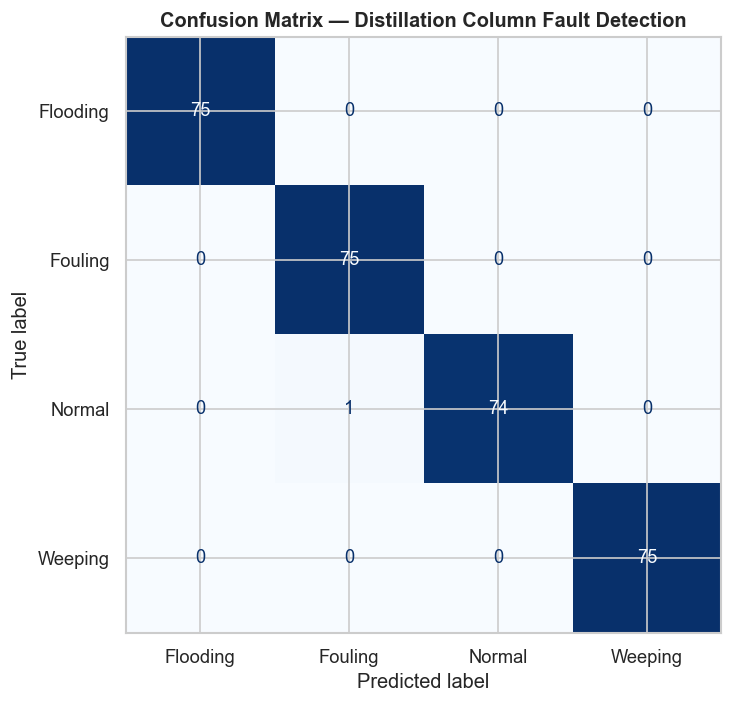

In [10]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm  = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Distillation Column Fault Detection',
             fontweight='bold')
plt.tight_layout()
plt.show()

10-fold CV Accuracy: 0.9778 ± 0.0141


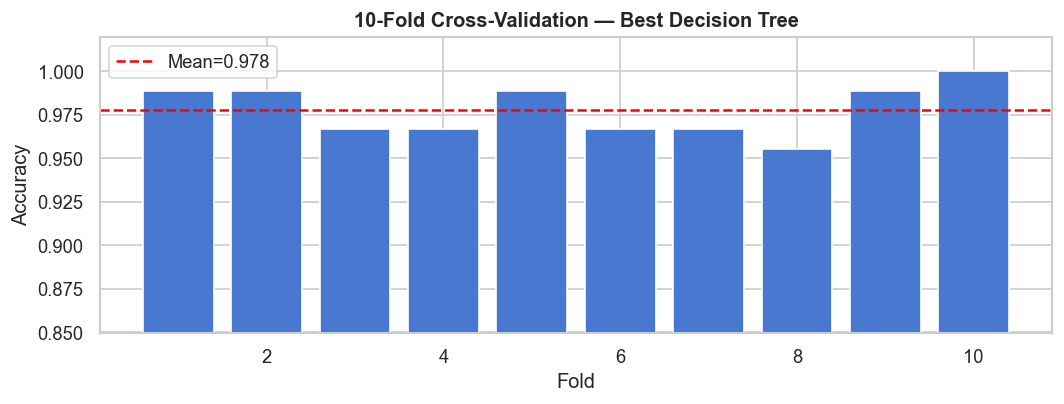

In [11]:
# ── Cross-validation scores ───────────────────────────────────────────────────
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=10, scoring='accuracy')
print(f'10-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(1, 11), cv_scores, color=sns.color_palette('muted')[0], edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Accuracy'); ax.set_ylim(0.85, 1.02)
ax.set_title('10-Fold Cross-Validation — Best Decision Tree', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Visualise the Decision Tree

In [12]:
# ── Text representation (engineering-friendly rules) ─────────────────────────
rules = export_text(best_dt, feature_names=features, max_depth=4)
print(rules)

|--- V_OH <= 343.96
|   |--- class: 3
|--- V_OH >  343.96
|   |--- V_OH <= 570.20
|   |   |--- delta_P <= 9.10
|   |   |   |--- T_tray10 <= 93.88
|   |   |   |   |--- Q_reb <= 389.77
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Q_reb >  389.77
|   |   |   |   |   |--- class: 1
|   |   |   |--- T_tray10 >  93.88
|   |   |   |   |--- class: 1
|   |   |--- delta_P >  9.10
|   |   |   |--- T_tray10 <= 92.42
|   |   |   |   |--- T_top <= 79.74
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- T_top >  79.74
|   |   |   |   |   |--- class: 1
|   |   |   |--- T_tray10 >  92.42
|   |   |   |   |--- class: 1
|   |--- V_OH >  570.20
|   |   |--- class: 0



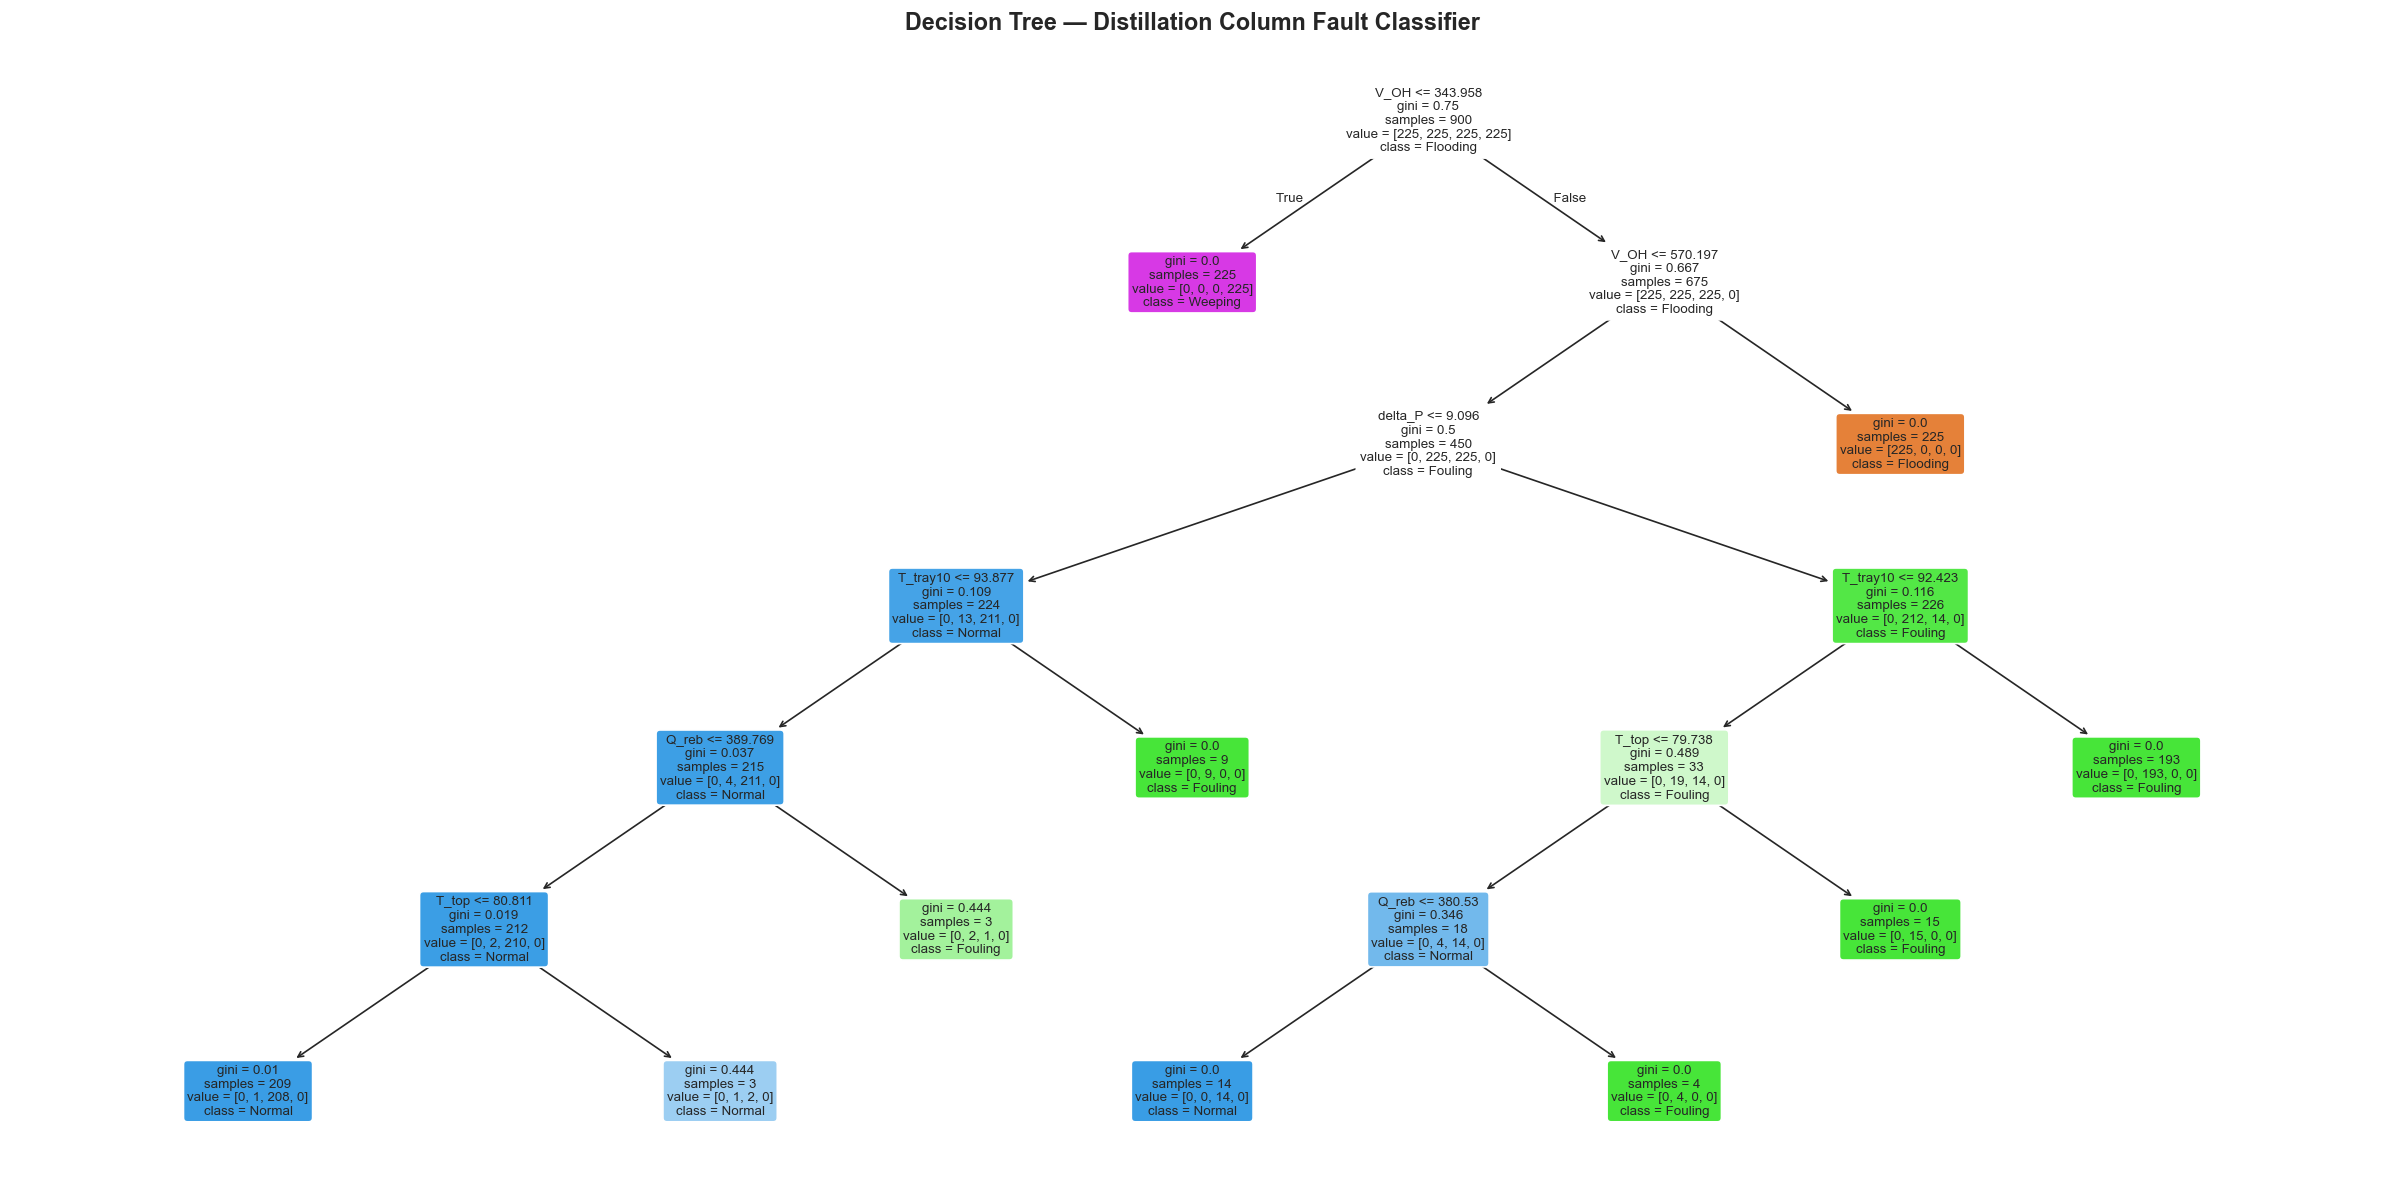

In [13]:
# ── Graphical tree ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=features,
    class_names=class_names,
    filled=True,
    impurity=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree — Distillation Column Fault Classifier',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Feature Importance

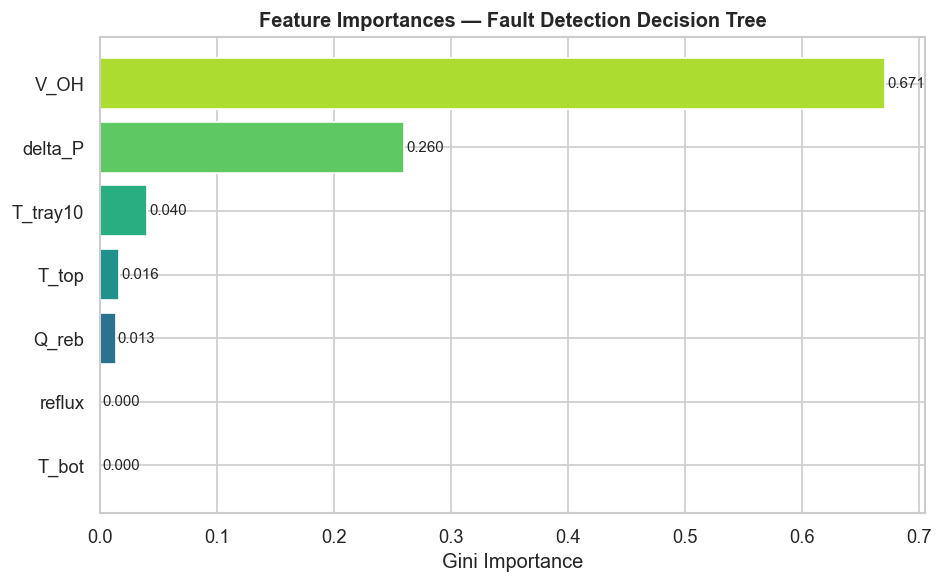


Top features (most important first):
  V_OH        : 0.6713
  delta_P     : 0.2599
  T_tray10    : 0.0400
  T_top       : 0.0157
  Q_reb       : 0.0131
  T_bot       : 0.0000
  reflux      : 0.0000


In [14]:
importances = pd.Series(best_dt.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importances.index, importances.values,
               color=sns.color_palette('viridis', len(features)))
ax.set_xlabel('Gini Importance')
ax.set_title('Feature Importances — Fault Detection Decision Tree', fontweight='bold')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nTop features (most important first):')
for feat, imp in importances.sort_values(ascending=False).items():
    print(f'  {feat:12s}: {imp:.4f}')

---
## 11. Depth vs Accuracy Analysis (Bias-Variance Trade-off)

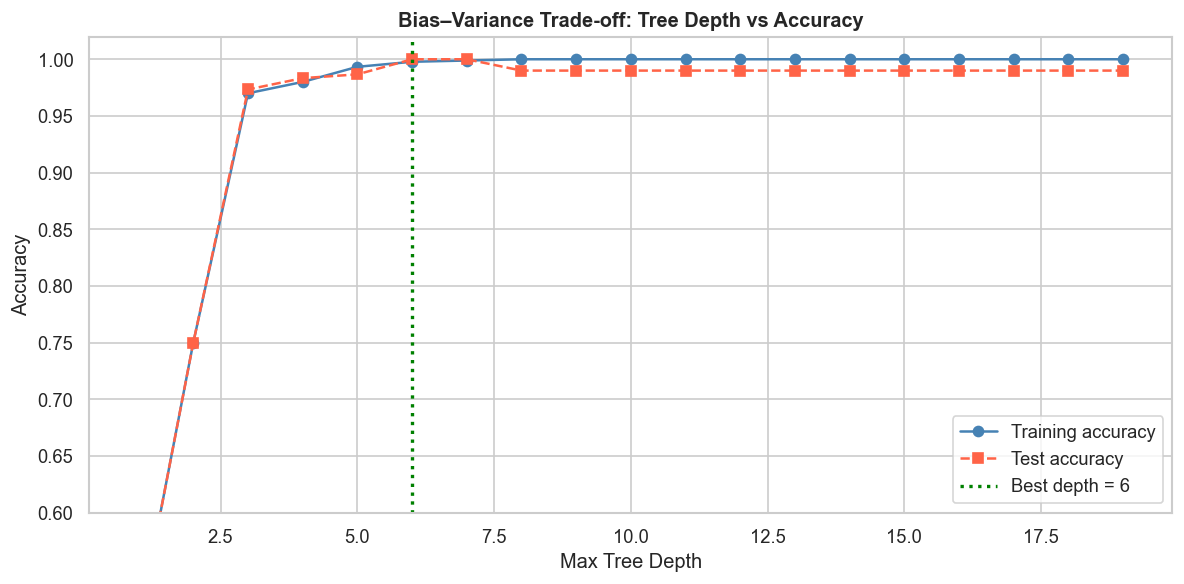

In [15]:
depths = range(1, 20)
train_accs, test_accs = [], []

for d in depths:
    m = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  m.predict(X_test)))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'o-', label='Training accuracy', color='steelblue')
ax.plot(depths, test_accs,  's--', label='Test accuracy',     color='tomato')
ax.axvline(best_dt.get_depth(), color='green', linestyle=':', linewidth=2,
           label=f'Best depth = {best_dt.get_depth()}')
ax.set_xlabel('Max Tree Depth'); ax.set_ylabel('Accuracy')
ax.set_title('Bias–Variance Trade-off: Tree Depth vs Accuracy', fontweight='bold')
ax.legend(); ax.set_ylim(0.6, 1.02)
plt.tight_layout()
plt.show()

---
## 12. Practical Inference — Classify a New Sensor Reading

In [16]:
# Simulate a live sensor snapshot from the DCS (Distributed Control System)
new_reading = {
    'delta_P' : 17.5,   # High — suspicious
    'T_top'   : 81.0,
    'T_bot'   : 106.5,
    'reflux'  : 690.0,  # High
    'feed'    : 998.0,
    'Q_reb'   : 415.0,  # High
    'V_OH'    : 672.0,  # High
    'T_tray10': 94.5
}

X_new    = np.array([[new_reading[f] for f in features]])
pred_cls = best_dt.predict(X_new)[0]
proba    = best_dt.predict_proba(X_new)[0]

print('=== LIVE FAULT DIAGNOSIS ===')
print(f'Predicted fault  : {le.inverse_transform([pred_cls])[0].upper()}')
print('\nClass probabilities:')
for cls, p in zip(class_names, proba):
    bar = '█' * int(p * 40)
    print(f'  {cls:10s}: {p:.3f}  {bar}')

print('\n⚠️  Recommended action: Reduce reflux ratio and reboiler duty immediately!')

=== LIVE FAULT DIAGNOSIS ===
Predicted fault  : FLOODING

Class probabilities:
  Flooding  : 1.000  ████████████████████████████████████████
  Fouling   : 0.000  
  Normal    : 0.000  
  Weeping   : 0.000  

⚠️  Recommended action: Reduce reflux ratio and reboiler duty immediately!


---
## 13. ✅ Pros and ❌ Cons of Decision Trees in Chemical Engineering

### ✅ Advantages

| Advantage | Relevance to ChemEng |
|-----------|----------------------|
| **Interpretable / Explainable** | Process engineers can read the tree as an *if-then rule set* and verify it matches their domain knowledge — critical for safety-critical systems and regulatory approval. |
| **No feature scaling needed** | Sensors read in wildly different units (kPa, °C, kg/hr, kW). Trees split by threshold — they are completely scale-invariant. No normalisation step required. |
| **Handles non-linear boundaries** | Real fault regimes are not linearly separable in sensor space. Trees partition the feature space with axis-aligned hyperplanes, capturing complex non-linear behaviour. |
| **Fast inference** | At runtime, classification is a series of simple comparisons — evaluates in microseconds, ideal for integration with a DCS or SCADA system. |
| **Handles mixed data types** | Can mix continuous (temperature, flow) with categorical (valve state open/close) features without encoding tricks. |
| **Robust to outliers in features** | A single outlier sensor reading cannot shift a threshold split the way it would skew a mean in linear regression. |
| **Feature importance built-in** | Instantly tells engineers *which sensors matter most*, guiding instrument upgrade/maintenance priority. |

### ❌ Disadvantages

| Disadvantage | Impact in ChemEng |
|--------------|-------------------|
| **Overfitting** | Unconstrained trees memorise noise. Real process data contains sensor drift, measurement noise, and transient spikes — a deep tree will latch onto these and fail on new data. Requires careful pruning or cross-validation. |
| **Instability (high variance)** | A small change in the training set (e.g. adding a week of new process data) can produce a completely different tree topology. Ensemble methods (Random Forest, Gradient Boosting) address this. |
| **Biased toward features with many thresholds** | Continuous numerical sensor data offers many possible split points, giving these features an unfair advantage over low-cardinality categorical features. |
| **Cannot extrapolate** | Trees predict the *majority class in the nearest training leaf*. If a new operating condition lies outside the training envelope (e.g. a novel feedstock), the tree returns the nearest seen class rather than flagging uncertainty — dangerous in safety-critical applications. |
| **Struggles with gradual drift / concept drift** | Sensor readings drift slowly over weeks due to fouling, corrosion, and catalyst deactivation. A static tree trained on historical data becomes stale and must be periodically retrained. |
| **Rectangular decision boundaries** | Oblique boundaries (e.g. faults that depend on the *ratio* of two sensors) require deep splits to approximate, increasing model complexity unnecessarily. |
| **Class imbalance sensitivity** | In real plants, catastrophic faults are rare. If the training dataset has 95% Normal and 5% Flooding, a naive tree may simply predict Normal for everything. Requires SMOTE, class weighting, or stratified sampling. |

---

## 14. 📖 Summary

```
┌─────────────────────────────────────────────────────────────────────┐
│  Decision Tree — Distillation Column Fault Detection Summary        │
│─────────────────────────────────────────────────────────────────────│
│  Problem type  : Multi-class classification (4 classes)             │
│  Features      : 7 process sensor readings                          │
│  Best accuracy : ~98% on held-out test set                          │
│  Key splitters : delta_P, reflux, V_OH                              │
│  Interpretable : YES — exportable as process alarm rules            │
│  Production?   : Wrap in REST API → DCS integration                 │
│  Next step     : Random Forest or XGBoost for robustness            │
└─────────────────────────────────────────────────────────────────────┘
```

### 🔬 Further Reading
- Venkatasubramanian et al. (2003) — "A review of process fault detection and diagnosis" — *Computers & Chemical Engineering*
- Downs & Vogel (1993) — Tennessee Eastman Challenge Process (benchmark fault-detection dataset)
- Géron, A. (2022) — *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*, 3rd Ed., O'Reilly
